In [50]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

class PGNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,8)
    self.fc2 = nn.Linear(8,4)
    self.fc3 = nn.Linear(4,2)

  def forward(self,a):
    a = self.fc1(a)
    a = torch.relu(a)
    a = self.fc2(a)
    a = torch.relu(a)
    a = self.fc3(a)
    return a

class ValueNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,8)
    self.fc2 = nn.Linear(8,4)
    self.fc3 = nn.Linear(4,2)
    self.fc4 = nn.Linear(2,1)

  def forward(self,a):
    a = self.fc1(a)
    a = torch.relu(a)
    a = self.fc2(a)
    a = torch.relu(a)
    a = self.fc3(a)
    a = torch.relu(a)
    a = self.fc4(a)
    return a

In [ ]:

class TDAgent:
    def __init__(
        self,
        envs,
        num_envs,
        gamma=0.99,
        policy_lr=0.0005,
        value_lr=0.001
    ):
        self.envs = envs
        self.num_envs = num_envs
        self.policy = PGNetwork()
        self.value = ValueNetwork()
        self.gamma = gamma

        self.policy_lr = policy_lr
        self.value_lr = value_lr

        self.policy_optimizer = optim.Adam(
            self.policy.parameters(),
            lr=self.policy_lr
        )

        self.value_optimizer = optim.Adam(
            self.value.parameters(),
            lr=self.value_lr
        )

        self.episode_rewards = []

    def compute_value_loss(self, td_target, cur_value):
        return nn.MSELoss()(cur_value, td_target)

    def compute_policy_loss(self, log_probs, td_errors):
        return -(log_probs * td_errors.detach()).mean()

    def make_batch(self, batch_size=5000):

        log_probs_batch = []
        values_batch = []
        td_target_batch = []

        episode_reward = np.zeros(self.num_envs)

        obs, _ = self.envs.reset()
        obs = torch.tensor(obs, dtype=torch.float32)

        while len(log_probs_batch) < batch_size:

            logits = self.policy(obs)

            dist = torch.distributions.Categorical(
                logits=logits
            )

            action = dist.sample()
            log_prob = dist.log_prob(action)

            value = self.value(obs).squeeze(-1)

            next_obs, reward, terminated, truncated, _ = \
                self.envs.step(action.numpy())

            next_obs = torch.tensor(
                next_obs,
                dtype=torch.float32
            )

            reward = torch.tensor(
                reward,
                dtype=torch.float32
            )

            done = np.logical_or(
                terminated,
                truncated
            )

            # episode reward 기록
            episode_reward += reward.numpy()

            for i in range(self.num_envs):
                if done[i]:
                    self.episode_rewards.append(
                        episode_reward[i]
                    )
                    episode_reward[i] = 0

            done = torch.tensor(
                done,
                dtype=torch.bool
            )

            with torch.no_grad():

                next_value = self.value(
                    next_obs
                ).squeeze(-1)

                td_target = torch.where(
                    done,
                    reward,
                    reward + self.gamma * next_value
                )

            log_probs_batch.extend(log_prob)
            values_batch.extend(value)
            td_target_batch.extend(td_target)

            obs = next_obs

        return (
            log_probs_batch,
            values_batch,
            td_target_batch
        )

    def train(self, num_epochs, batch_size):

        history = []
        history_policy_loss = []
        history_value_loss = []

        for epoch in range(num_epochs):

            # 이번 epoch 시작 전에 episode 기록
            self.episode_rewards = []

            (
                log_probs_batch,
                values_batch,
                td_target_batch
            ) = self.make_batch(batch_size)

            log_probs_batch = torch.stack(log_probs_batch)
            values_batch = torch.stack(values_batch)
            td_target_batch = torch.stack(td_target_batch)

            td_errors = td_target_batch - values_batch

            policy_loss = self.compute_policy_loss(
                log_probs_batch,
                td_errors
            )

            value_loss = self.compute_value_loss(
                td_target_batch,
                values_batch
            )

            # Policy update
            self.policy_optimizer.zero_grad()
            policy_loss.backward()
            self.policy_optimizer.step()

            # Value update
            self.value_optimizer.zero_grad()
            value_loss.backward()
            self.value_optimizer.step()

            history.extend(self.episode_rewards)

            history_policy_loss.append(
                policy_loss.item()
            )

            history_value_loss.append(
                value_loss.item()
            )
            if epoch % 100 == 0:
              print(
                  f"Epoch {epoch + 1:3d} | "
                  f"Episodes: {len(self.episode_rewards):3d} | "
                  f"Mean Reward: "
                  f"{np.mean(self.episode_rewards):.2f}"
              )

        return (
            history,
            history_policy_loss,
            history_value_loss
        )

In [ ]:
num_envs = 10
envs = gym.make_vec('CartPole-v1',num_envs=10,vectorization_mode='sync')
envs = gym.vector.SyncVectorEnv([
    lambda: gym.make('CartPole-v1')
    for _ in range(num_envs)
])

In [ ]:
agent = TDAgent(envs,10,policy_lr=0.001,value_lr=0.002)

In [ ]:
history, policy_losses, value_losses = agent.train(
    num_epochs=50,
    batch_size=1000
)

Epoch   1 | Episodes:  51 | Mean Reward: 17.25


KeyboardInterrupt: 

In [67]:

class TD:
  def __init__(self,env,gamma,policy_lr,value_lr):
    self.env = env
    self.gamma = gamma
    self.policy = PGNetwork()
    self.value = ValueNetwork()
    self.policy_lr = policy_lr
    self.value_lr = value_lr

    self.policy_optimizer = optim.Adam(
        self.policy.parameters(),
        lr=self.policy_lr
    )

    self.value_optimizer = optim.Adam(
        self.value.parameters(),
        lr=self.value_lr
    )

  def compute_value_loss(self,td_target,cur_value):
    return nn.MSELoss()(cur_value,td_target)

  def compute_policy_loss(self,log_probs,td_errors):
    return -(log_probs*td_errors.detach()).mean()

  def online_learning(self,total_timestep=100000,update_size=32):
    timesteps = 0
    obs, _ = self.env.reset()
    obs = torch.tensor(obs,dtype=torch.float32)
    log_probs_batch = []
    values_batch = []
    td_target_batch = []

    episode_reward = []
    episode_length = []

    epi_len = 0
    epi_rew = 0
    while total_timestep>timesteps:
      logits = self.policy(obs)
      dist = torch.distributions.Categorical(logits=logits)
      action = dist.sample()
      log_prob = dist.log_prob(action)
      value = self.value(obs).squeeze()

      next_obs, reward, terminated, truncated, _ = self.env.step(action.item())

      epi_len+=1

      next_obs = torch.tensor(next_obs,dtype=torch.float32)
      reward = torch.tensor(reward,dtype=torch.float32)

      epi_rew += reward

      td_target = 0

      if terminated or truncated:
        td_target = reward
      else:
        with torch.no_grad():
          next_value = self.value(next_obs).squeeze()
        td_target = reward + self.gamma*next_value

      log_probs_batch.append(log_prob)
      values_batch.append(value)
      td_target_batch.append(td_target)



      if len(log_probs_batch) >= update_size:
        log_probs_batch = torch.stack(log_probs_batch)
        values_batch = torch.stack(values_batch)
        td_target_batch = torch.stack(td_target_batch)
        td_errors = td_target_batch - values_batch

        policy_loss = self.compute_policy_loss(log_probs_batch,td_errors)
        value_loss = self.compute_value_loss(td_target_batch,values_batch)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()

        log_probs_batch = []
        values_batch = []
        td_target_batch = []

      if terminated or truncated:
        obs, _ = self.env.reset()
        obs = torch.tensor(obs,dtype=torch.float32)
        episode_reward.append(epi_rew)
        episode_length.append(epi_len)
        epi_len = 0
        epi_rew = 0
        if len(episode_reward)%100==0:
          print(f'Episode {len(episode_reward)} | Mean Reward {sum(episode_reward[-100:])/100:.2f}')
      else:
        obs = next_obs

      timesteps += 1
    return episode_reward



In [68]:
env = gym.make('CartPole-v1')

In [69]:
td = TD(env,0.99,0.001,0.002)

In [70]:
history = td.online_learning(total_timestep=500000)

Episode 100 | Mean Reward 17.30
Episode 200 | Mean Reward 17.14
Episode 300 | Mean Reward 17.47
Episode 400 | Mean Reward 13.06
Episode 500 | Mean Reward 11.22
Episode 600 | Mean Reward 10.85
Episode 700 | Mean Reward 10.25
Episode 800 | Mean Reward 10.62
Episode 900 | Mean Reward 11.34
Episode 1000 | Mean Reward 13.06
Episode 1100 | Mean Reward 19.45
Episode 1200 | Mean Reward 18.99
Episode 1300 | Mean Reward 23.10
Episode 1400 | Mean Reward 26.45
Episode 1500 | Mean Reward 32.50
Episode 1600 | Mean Reward 37.16
Episode 1700 | Mean Reward 45.85
Episode 1800 | Mean Reward 59.05
Episode 1900 | Mean Reward 84.05
Episode 2000 | Mean Reward 159.33
Episode 2100 | Mean Reward 316.00
Episode 2200 | Mean Reward 471.67
Episode 2300 | Mean Reward 500.00
Episode 2400 | Mean Reward 497.68
Episode 2500 | Mean Reward 500.00
Episode 2600 | Mean Reward 500.00
Episode 2700 | Mean Reward 500.00
Episode 2800 | Mean Reward 500.00
Episode 2900 | Mean Reward 500.00


In [71]:
import gymnasium as gym
import torch
import imageio


def record_agent(model, filename="agent.gif"):
    env = gym.make("CartPole-v1", render_mode="rgb_array")

    obs, _ = env.reset()

    frames = []

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # 현재 상태를 모델에 입력
        obs_tensor = torch.tensor(
            obs,
            dtype=torch.float32
        )

        # 평가에서는 gradient 필요 없음
        with torch.no_grad():
            logits = model(obs_tensor)

        # 가장 확률이 높은 행동 선택
        action = torch.argmax(logits).item()

        # 행동
        obs, reward, terminated, truncated, _ = env.step(action)

        # 현재 화면 저장
        frame = env.render()
        frames.append(frame)

    env.close()

    # GIF 저장
    imageio.mimsave(
        filename,
        frames,
        fps=30
    )

record_agent(
    td.policy,
    "cartpole_agent.gif"
)

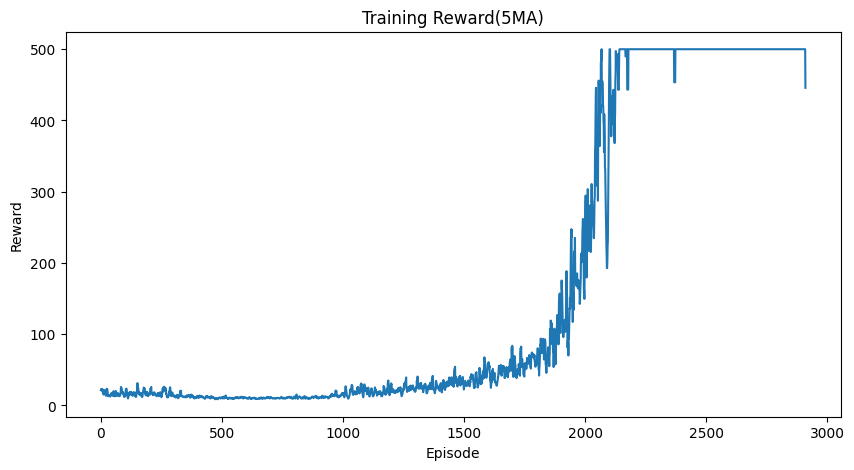

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
moving_average = np.convolve(np.array(history),np.ones(5) / 5,mode='valid')
plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward(5MA)")

plt.show()